In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

Executing on: cuda


In [ ]:
df = pd.read_csv("/content/IMDB-Dataset.csv", on_bad_lines="skip", engine='python').head(50000)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.shape

(50000, 2)

In [ ]:
# Improved text cleaning function
def clean_text(text):
    text = re.sub(r'<[^>]+>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Keep only letters
    text = text.lower().strip()
    return text

In [ ]:
df = df.dropna()
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'].astype(str))

df['cleaned_review'] = df['review'].apply(clean_text)
df['review_split'] = df['cleaned_review'].str.split()

In [ ]:
df.head()

,review,sentiment,cleaned_review,review_split
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin..."
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,Basically there's a family where a little boy ...,0,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon..."


In [ ]:
all_words = [word for review in df['review_split'] for word in review]
vocab = sorted(list(set(all_words)))
word_to_idx = {word: idx + 1 for idx, word in enumerate(vocab)}
vocab_size = len(word_to_idx) + 1

max_seq_len = 200

In [ ]:
word_to_idx

{'a': 1,
 'aa': 2,
 'aaa': 3,
 'aaaaaaaaaaaahhhhhhhhhhhhhh': 4,
 'aaaaaaaargh': 5,
 'aaaaaaah': 6,
 'aaaaaaahhhhhhggg': 7,
 'aaaaagh': 8,
 'aaaaah': 9,
 'aaaaargh': 10,
 'aaaaarrrrrrgggggghhhhhh': 11,
 'aaaaatchkah': 12,
 'aaaaaw': 13,
 'aaaahhhhhh': 14,
 'aaaahhhhhhh': 15,
 'aaaand': 16,
 'aaaarrgh': 17,
 'aaaawwwwww': 18,
 'aaaggghhhhhhh': 19,
 'aaaghi': 20,
 'aaah': 21,
 'aaahhhhhhh': 22,
 'aaahthe': 23,
 'aaall': 24,
 'aaand': 25,
 'aaargh': 26,
 'aaarghhow': 27,
 'aaarrrghim': 28,
 'aaaugh': 29,
 'aab': 30,
 'aachen': 31,
 'aada': 32,
 'aadha': 33,
 'aadmittedly': 34,
 'aag': 35,
 'aage': 36,
 'aagh': 37,
 'aaghh': 38,
 'aah': 39,
 'aahed': 40,
 'aahemy': 41,
 'aahhh': 42,
 'aahhhh': 43,
 'aahing': 44,
 'aaila': 45,
 'aailiyah': 46,
 'aaip': 47,
 'aaja': 48,
 'aajala': 49,
 'aak': 50,
 'aakash': 51,
 'aake': 52,
 'aaker': 53,
 'aakrosh': 54,
 'aalcc': 55,
 'aaliyah': 56,
 'aaliyahs': 57,
 'aalox': 58,
 'aames': 59,
 'aamess': 60,
 'aamesthe': 61,
 'aamilne': 62,
 'aamir': 63,
 'aa

In [ ]:
def encode_safe(text_list):
    encoded = [min(word_to_idx.get(w, 0), vocab_size - 1) for w in text_list]
    encoded = encoded[:max_seq_len]
    return encoded + [0] * (max_seq_len - len(encoded))

df['encoded_review'] = df['review_split'].apply(encode_safe)
df.head()

,review,sentiment,cleaned_review,review_split,encoded_review
0,One of the other reviewers has mentioned that ...,1,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione...","[133558, 132229, 188008, 135423, 157007, 83221..."
1,A wonderful little production. <br /><br />The...,1,a wonderful little production the filming tech...,"[a, wonderful, little, production, the, filmin...","[1, 210192, 108988, 148160, 188008, 67230, 186..."
2,I thought this was a wonderful way to spend ti...,1,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,...","[90815, 190058, 189572, 205110, 1, 210192, 205..."
3,Basically there's a family where a little boy ...,0,basically theres a family where a little boy j...,"[basically, theres, a, family, where, a, littl...","[15215, 188902, 1, 64233, 207891, 1, 108988, 2..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter matteis love in the time of money is a ...,"[petter, matteis, love, in, the, time, of, mon...","[141409, 115546, 110633, 92527, 188008, 191045..."


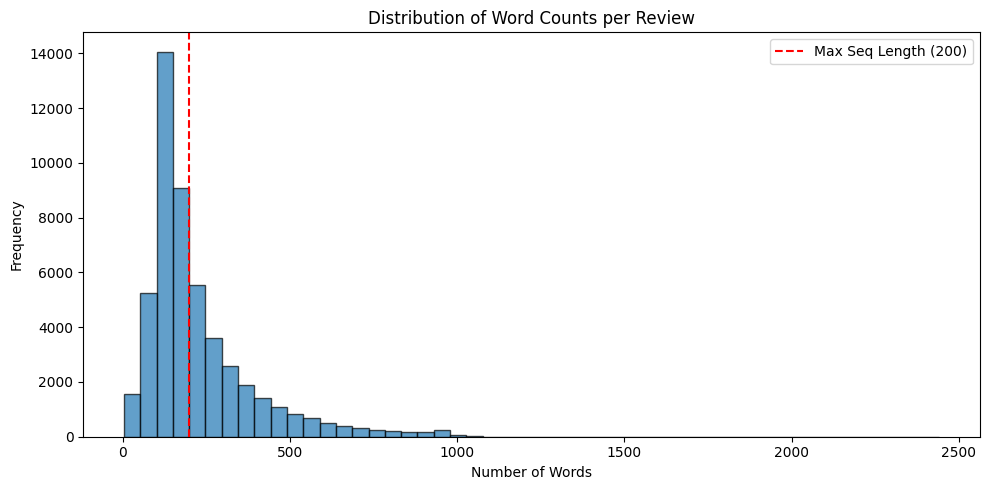

In [ ]:
# ============ VISUALIZATION 1: Histogram of Word Counts ============
df['word_count'] = df['review_split'].apply(len)

plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts per Review')
plt.axvline(x=max_seq_len, color='red', linestyle='--', label=f'Max Seq Length ({max_seq_len})')
plt.legend()
plt.tight_layout()
plt.show()

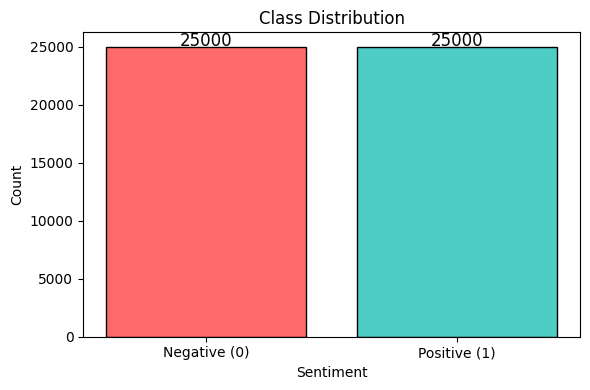

In [ ]:
# ============ VISUALIZATION 2: Class Balance ============
plt.figure(figsize=(6, 4))
sentiment_counts = df['sentiment'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
bars = plt.bar(['Negative (0)', 'Positive (1)'], sentiment_counts.values, color=colors, edgecolor='black')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Class Distribution')
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ============ VISUALIZATION 3: Word Clouds ============
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Positive reviews word cloud
positive_words = ' '.join(df[df['sentiment'] == 1]['cleaned_review'])
wc_pos = WordCloud(width=600, height=400, background_color='white',
                   colormap='Greens', max_words=100).generate(positive_words)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Positive Reviews', fontsize=14)
axes[0].axis('off')

# Negative reviews word cloud
negative_words = ' '.join(df[df['sentiment'] == 0]['cleaned_review'])
wc_neg = WordCloud(width=600, height=400, background_color='white',
                   colormap='Reds', max_words=100).generate(negative_words)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()


[Output removed — too large for GitHub rendering]


In [ ]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, data):
        # We use the actual column names from our dataframe
        self.texts = list(data['encoded_review'])
        self.labels = list(data['sentiment'])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.texts[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

train_loader = DataLoader(SentimentDataset(train_data), batch_size=32, shuffle=True)
test_loader = DataLoader(SentimentDataset(test_data), batch_size=32, shuffle=False)

In [ ]:
for x, y in train_loader:
    print(x.shape, y.shape)

    break

torch.Size([32, 200]) torch.Size([32])


# Original Models (Before Fixing)

Training the original RNN, LSTM, and GRU models to capture their baseline performance and validation loss curves for comparison.

In [ ]:
# ============ Original RNN Model ============
class OriginalRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, dropout=0.5):
        super(OriginalRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers=2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        h0 = torch.zeros(self.rnn.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(embedded, h0)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)

# Original training function (no scheduler, no gradient clipping)
def train_model_original(model, train_loader, val_loader, optimizer, criterion, epochs=15, patience=5):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(100 * train_correct / train_total)
        history['val_acc'].append(100 * val_correct / val_total)

        duration = time.time() - start_time
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | '
              f'Train Acc: {history["train_acc"][-1]:.2f}% | Val Acc: {history["val_acc"][-1]:.2f}% | {duration:.1f}s')

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping at epoch {epoch+1}!')
                break

    return history

In [ ]:
# Train Original RNN
orig_rnn_model = OriginalRNN(vocab_size, embed_size=128, hidden_size=128, output_size=2, dropout=0.5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(orig_rnn_model.parameters(), lr=0.0005, weight_decay=1e-4)
orig_rnn_history = train_model_original(orig_rnn_model, train_loader, test_loader, optimizer, criterion)

Epoch 1/15 | Train Loss: 0.6970 | Val Loss: 0.6934 | Train Acc: 49.98% | Val Acc: 50.43% | 4.6s
Epoch 2/15 | Train Loss: 0.6937 | Val Loss: 0.6934 | Train Acc: 50.57% | Val Acc: 50.45% | 3.7s
Epoch 3/15 | Train Loss: 0.6925 | Val Loss: 0.6917 | Train Acc: 51.53% | Val Acc: 51.99% | 3.7s
Epoch 4/15 | Train Loss: 0.6943 | Val Loss: 0.6923 | Train Acc: 51.04% | Val Acc: 51.69% | 3.7s
Epoch 5/15 | Train Loss: 0.6937 | Val Loss: 0.6959 | Train Acc: 50.71% | Val Acc: 48.75% | 3.7s
Epoch 6/15 | Train Loss: 0.6940 | Val Loss: 0.6950 | Train Acc: 50.85% | Val Acc: 49.61% | 3.8s
Epoch 7/15 | Train Loss: 0.6924 | Val Loss: 0.6897 | Train Acc: 51.68% | Val Acc: 54.05% | 3.8s
Epoch 8/15 | Train Loss: 0.6920 | Val Loss: 0.6923 | Train Acc: 52.72% | Val Acc: 51.60% | 3.8s
Epoch 9/15 | Train Loss: 0.6924 | Val Loss: 0.6910 | Train Acc: 51.84% | Val Acc: 50.41% | 3.8s
Epoch 10/15 | Train Loss: 0.6959 | Val Loss: 0.6978 | Train Acc: 51.00% | Val Acc: 48.64% | 3.8s
Epoch 11/15 | Train Loss: 0.6961 | Val 

In [ ]:
# ============ Original LSTM Model ============
class OriginalLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(OriginalLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        out, (hn, cn) = self.lstm(embedded)
        last_step = out[:, -1, :]
        last_step = self.dropout(last_step)
        return self.fc(last_step)

# Train Original LSTM
orig_lstm_model = OriginalLSTM(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(orig_lstm_model.parameters(), lr=0.001)
orig_lstm_history = train_model_original(orig_lstm_model, train_loader, test_loader, optimizer, criterion, epochs=15)

Epoch 1/15 | Train Loss: 0.6913 | Val Loss: 0.6886 | Train Acc: 51.95% | Val Acc: 52.66% | 5.9s
Epoch 2/15 | Train Loss: 0.6879 | Val Loss: 0.6437 | Train Acc: 52.69% | Val Acc: 65.94% | 5.9s
Epoch 3/15 | Train Loss: 0.5140 | Val Loss: 0.5000 | Train Acc: 75.71% | Val Acc: 75.08% | 5.9s
Epoch 4/15 | Train Loss: 0.3228 | Val Loss: 0.3345 | Train Acc: 87.11% | Val Acc: 85.29% | 5.9s
Epoch 5/15 | Train Loss: 0.2164 | Val Loss: 0.3684 | Train Acc: 92.23% | Val Acc: 85.99% | 5.9s
Epoch 6/15 | Train Loss: 0.1452 | Val Loss: 0.4001 | Train Acc: 95.19% | Val Acc: 86.50% | 5.9s
Epoch 7/15 | Train Loss: 0.0896 | Val Loss: 0.4338 | Train Acc: 97.33% | Val Acc: 86.07% | 5.9s
Epoch 8/15 | Train Loss: 0.0545 | Val Loss: 0.4801 | Train Acc: 98.53% | Val Acc: 85.54% | 5.9s
Epoch 9/15 | Train Loss: 0.0365 | Val Loss: 0.5817 | Train Acc: 99.10% | Val Acc: 85.77% | 5.8s
Early stopping at epoch 9!


In [ ]:
# ============ Original GRU Model ============
class OriginalGRU(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(OriginalGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True, num_layers=2, dropout=0.3)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embedding(x)
        out, hn = self.gru(embedded)
        last_step = out[:, -1, :]
        last_step = self.dropout(last_step)
        return self.fc(last_step)

# Train Original GRU
orig_gru_model = OriginalGRU(vocab_size, 128, 128, 2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(orig_gru_model.parameters(), lr=0.001)
orig_gru_history = train_model_original(orig_gru_model, train_loader, test_loader, optimizer, criterion, epochs=15)

Epoch 1/15 | Train Loss: 0.6971 | Val Loss: 0.6920 | Train Acc: 51.34% | Val Acc: 52.35% | 3.9s
Epoch 2/15 | Train Loss: 0.5546 | Val Loss: 0.3375 | Train Acc: 67.84% | Val Acc: 85.14% | 3.9s
Epoch 3/15 | Train Loss: 0.2799 | Val Loss: 0.2952 | Train Acc: 88.31% | Val Acc: 87.51% | 3.8s
Epoch 4/15 | Train Loss: 0.1599 | Val Loss: 0.3343 | Train Acc: 94.11% | Val Acc: 87.40% | 3.8s
Epoch 5/15 | Train Loss: 0.0758 | Val Loss: 0.4351 | Train Acc: 97.54% | Val Acc: 86.87% | 3.8s
Epoch 6/15 | Train Loss: 0.0320 | Val Loss: 0.5069 | Train Acc: 99.09% | Val Acc: 86.26% | 3.8s
Epoch 7/15 | Train Loss: 0.0208 | Val Loss: 0.6305 | Train Acc: 99.36% | Val Acc: 86.52% | 3.8s
Epoch 8/15 | Train Loss: 0.0151 | Val Loss: 0.6307 | Train Acc: 99.51% | Val Acc: 86.76% | 3.8s
Early stopping at epoch 8!


# ═════════════════════════════
#  Fixing the Models
# ═════════════════════════════

### Techniques Applied:
- **Multi-position Dropout**: Embedding dropout + recurrent dropout + output dropout
- **Reduced Model Capacity**: Smaller hidden_size (64), single layer for RNN; controlled capacity for LSTM/GRU
- **Gradient Clipping**: `clip_grad_norm_()` to prevent exploding gradients
- **Learning Rate Scheduler**: `ReduceLROnPlateau` to adaptively reduce LR
- **Robust Early Stopping**: With best model checkpoint restoration
- **Weight Decay (L2 Regularization)**: Applied via optimizer
- **Bidirectional layers**: For LSTM and GRU to capture context from both directions
- **Attention pooling**: Weighted average of hidden states instead of just last timestep

In [ ]:
# ============ Improved Training Function ============
# Includes: gradient clipping, LR scheduler, early stopping with checkpoint, validation split

from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.utils import clip_grad_norm_

# Create a proper validation split from training data
train_subset, val_subset = train_test_split(train_data, test_size=0.15, random_state=42)
train_loader_new = DataLoader(SentimentDataset(train_subset), batch_size=64, shuffle=True)
val_loader_new = DataLoader(SentimentDataset(val_subset), batch_size=64, shuffle=False)
test_loader_new = DataLoader(SentimentDataset(test_data), batch_size=64, shuffle=False)

print(f'Training samples: {len(train_subset)}')
print(f'Validation samples: {len(val_subset)}')
print(f'Test samples: {len(test_data)}')

def train_model_improved(model, train_loader, val_loader, epochs=25, patience=7,
                         lr=0.001, weight_decay=1e-5, clip_value=1.0, model_name='Model'):
    """
    Advanced training loop with:
    - Gradient clipping (clip_grad_norm_)
    - ReduceLROnPlateau scheduler
    - Early stopping with best model checkpoint restoration
    - L2 regularization via weight_decay
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) # Removed verbose=True

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    print(f'\n{"="*60}')
    print(f'Training {model_name}')
    print(f'{"="*60}')

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for texts, labels in train_loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping to prevent exploding gradients
            clip_grad_norm_(model.parameters(), max_norm=clip_value)

            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for texts, labels in val_loader:
                texts, labels = texts.to(device), labels.to(device)
                outputs = model(texts)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # Step the scheduler based on validation loss
        scheduler.step(avg_val_loss)

        current_lr = optimizer.param_groups[0]['lr']
        duration = time.time() - start_time
        print(f'Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Val Acc: {val_acc:.2f}% | LR: {current_lr:.6f} | {duration:.1f}s')

        # Early stopping with best model checkpoint
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}! Best Val Loss: {best_val_loss:.4f}')
                break

    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f'Restored best model checkpoint (Val Loss: {best_val_loss:.4f})')

    return history

import copy as copy  # needed for deepcopy of state_dict

Training samples: 34000
Validation samples: 6000
Test samples: 10000


In [ ]:
# ============ Improved RNN ============
# Fix for underfitting: Increase capacity slightly, use bidirectional,
# add attention mechanism, reduce dropout

class ImprovedRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, dropout=0.3):
        super(ImprovedRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.embed_dropout = nn.Dropout(0.2)  # Light dropout on embeddings

        # Single layer RNN (simpler = easier to train for vanilla RNN)
        # Bidirectional to capture context from both directions
        self.rnn = nn.RNN(embed_size, hidden_size, num_layers=1,
                          batch_first=True, bidirectional=True)

        # Attention mechanism to weight important timesteps
        self.attention = nn.Linear(hidden_size * 2, 1)
        self.output_dropout = nn.Dropout(dropout)

        # BatchNorm for stability
        self.batch_norm = nn.BatchNorm1d(hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        embedded = self.embed_dropout(self.embedding(x))
        # out: (batch, seq_len, hidden_size * 2) because bidirectional
        out, _ = self.rnn(embedded)

        # Attention pooling over all timesteps
        attn_weights = torch.softmax(self.attention(out), dim=1)  # (batch, seq_len, 1)
        context = torch.sum(attn_weights * out, dim=1)  # (batch, hidden_size * 2)

        context = self.batch_norm(context)
        context = self.output_dropout(context)
        return self.fc(context)

# Train Improved RNN
improved_rnn = ImprovedRNN(vocab_size, embed_size=100, hidden_size=64,
                           output_size=2, dropout=0.3).to(device)
print(f'Improved RNN Parameters: {sum(p.numel() for p in improved_rnn.parameters()):,}')

improved_rnn_history = train_model_improved(
    improved_rnn, train_loader_new, val_loader_new,
    epochs=25, patience=7, lr=0.002, weight_decay=1e-5,
    clip_value=0.5, model_name='Improved RNN'
)

Improved RNN Parameters: 21,483,991

Training Improved RNN
Epoch  1/25 | Train Loss: 0.4725 | Val Loss: 0.3282 | Train Acc: 76.60% | Val Acc: 85.77% | LR: 0.002000 | 1.8s
Epoch  2/25 | Train Loss: 0.3196 | Val Loss: 0.2820 | Train Acc: 86.06% | Val Acc: 88.27% | LR: 0.002000 | 1.7s
Epoch  3/25 | Train Loss: 0.2493 | Val Loss: 0.2831 | Train Acc: 89.85% | Val Acc: 88.32% | LR: 0.002000 | 1.7s
Epoch  4/25 | Train Loss: 0.1851 | Val Loss: 0.3223 | Train Acc: 92.95% | Val Acc: 87.68% | LR: 0.002000 | 1.7s
Epoch  5/25 | Train Loss: 0.1263 | Val Loss: 0.3727 | Train Acc: 95.40% | Val Acc: 87.35% | LR: 0.002000 | 1.7s
Epoch  6/25 | Train Loss: 0.0898 | Val Loss: 0.4587 | Train Acc: 96.77% | Val Acc: 87.58% | LR: 0.001000 | 1.7s
Epoch  7/25 | Train Loss: 0.0532 | Val Loss: 0.5570 | Train Acc: 98.14% | Val Acc: 87.55% | LR: 0.001000 | 1.7s
Epoch  8/25 | Train Loss: 0.0302 | Val Loss: 0.6657 | Train Acc: 99.01% | Val Acc: 87.68% | LR: 0.001000 | 1.8s
Epoch  9/25 | Train Loss: 0.0270 | Val Loss: 

In [ ]:
# ============ Improved LSTM ============
# Fix for overfitting: Aggressive dropout, reduced hidden_size,
# weight decay, attention pooling, layer normalization

class ImprovedLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, dropout=0.5):
        super(ImprovedLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.embed_dropout = nn.Dropout(0.3)  # Dropout after embedding

        # Reduced to 1 layer with bidirectional (prevents inter-layer overfitting)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True,
                            num_layers=1, bidirectional=True)

        # Attention mechanism
        self.attention = nn.Linear(hidden_size * 2, 1)

        # Layer normalization instead of batch norm (works better with RNNs)
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.output_dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embed_dropout(self.embedding(x))
        out, _ = self.lstm(embedded)  # (batch, seq_len, hidden*2)

        # Attention pooling
        attn_weights = torch.softmax(self.attention(out), dim=1)
        context = torch.sum(attn_weights * out, dim=1)

        context = self.layer_norm(context)
        context = self.output_dropout(context)
        hidden = self.relu(self.fc1(context))
        hidden = self.output_dropout(hidden)
        return self.fc2(hidden)

# Train Improved LSTM
improved_lstm = ImprovedLSTM(vocab_size, embed_size=100, hidden_size=64,
                             output_size=2, dropout=0.5).to(device)
print(f'Improved LSTM Parameters: {sum(p.numel() for p in improved_lstm.parameters()):,}')

improved_lstm_history = train_model_improved(
    improved_lstm, train_loader_new, val_loader_new,
    epochs=25, patience=7, lr=0.001, weight_decay=1e-4,
    clip_value=1.0, model_name='Improved LSTM'
)

Improved LSTM Parameters: 21,555,863

Training Improved LSTM
Epoch  1/25 | Train Loss: 0.6055 | Val Loss: 0.4485 | Train Acc: 65.93% | Val Acc: 78.97% | LR: 0.001000 | 1.9s
Epoch  2/25 | Train Loss: 0.4468 | Val Loss: 0.3736 | Train Acc: 79.37% | Val Acc: 82.85% | LR: 0.001000 | 1.9s
Epoch  3/25 | Train Loss: 0.3794 | Val Loss: 0.3258 | Train Acc: 83.26% | Val Acc: 86.47% | LR: 0.001000 | 1.9s
Epoch  4/25 | Train Loss: 0.3267 | Val Loss: 0.2987 | Train Acc: 86.14% | Val Acc: 87.63% | LR: 0.001000 | 1.9s
Epoch  5/25 | Train Loss: 0.2926 | Val Loss: 0.2880 | Train Acc: 88.15% | Val Acc: 87.60% | LR: 0.001000 | 1.9s
Epoch  6/25 | Train Loss: 0.2627 | Val Loss: 0.2729 | Train Acc: 89.42% | Val Acc: 88.60% | LR: 0.001000 | 1.9s
Epoch  7/25 | Train Loss: 0.2385 | Val Loss: 0.2667 | Train Acc: 90.67% | Val Acc: 88.83% | LR: 0.001000 | 1.9s
Epoch  8/25 | Train Loss: 0.2157 | Val Loss: 0.2860 | Train Acc: 91.60% | Val Acc: 88.57% | LR: 0.001000 | 1.9s
Epoch  9/25 | Train Loss: 0.1891 | Val Loss

In [ ]:
# ============ Improved GRU ============
# Fix for overfitting: Similar strategy to LSTM fix

class ImprovedGRU(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size, dropout=0.5):
        super(ImprovedGRU, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.embed_dropout = nn.Dropout(0.3)

        # Reduced to 1 bidirectional layer
        self.gru = nn.GRU(embed_size, hidden_size, batch_first=True,
                          num_layers=1, bidirectional=True)

        # Attention mechanism
        self.attention = nn.Linear(hidden_size * 2, 1)

        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        self.output_dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size * 2, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        embedded = self.embed_dropout(self.embedding(x))
        out, _ = self.gru(embedded)

        # Attention pooling
        attn_weights = torch.softmax(self.attention(out), dim=1)
        context = torch.sum(attn_weights * out, dim=1)

        context = self.layer_norm(context)
        context = self.output_dropout(context)
        hidden = self.relu(self.fc1(context))
        hidden = self.output_dropout(hidden)
        return self.fc2(hidden)

# Train Improved GRU
improved_gru = ImprovedGRU(vocab_size, embed_size=100, hidden_size=64,
                           output_size=2, dropout=0.5).to(device)
print(f'Improved GRU Parameters: {sum(p.numel() for p in improved_gru.parameters()):,}')

improved_gru_history = train_model_improved(
    improved_gru, train_loader_new, val_loader_new,
    epochs=25, patience=7, lr=0.001, weight_decay=1e-4,
    clip_value=1.0, model_name='Improved GRU'
)

Improved GRU Parameters: 21,534,615

Training Improved GRU
Epoch  1/25 | Train Loss: 0.6043 | Val Loss: 0.4488 | Train Acc: 65.53% | Val Acc: 78.57% | LR: 0.001000 | 1.8s
Epoch  2/25 | Train Loss: 0.4360 | Val Loss: 0.3527 | Train Acc: 80.30% | Val Acc: 84.90% | LR: 0.001000 | 1.8s
Epoch  3/25 | Train Loss: 0.3683 | Val Loss: 0.3202 | Train Acc: 84.13% | Val Acc: 86.35% | LR: 0.001000 | 1.8s
Epoch  4/25 | Train Loss: 0.3210 | Val Loss: 0.2917 | Train Acc: 86.62% | Val Acc: 87.78% | LR: 0.001000 | 1.8s
Epoch  5/25 | Train Loss: 0.2890 | Val Loss: 0.2788 | Train Acc: 88.35% | Val Acc: 88.05% | LR: 0.001000 | 1.9s
Epoch  6/25 | Train Loss: 0.2574 | Val Loss: 0.2914 | Train Acc: 89.80% | Val Acc: 88.02% | LR: 0.001000 | 1.8s
Epoch  7/25 | Train Loss: 0.2333 | Val Loss: 0.2824 | Train Acc: 91.07% | Val Acc: 88.52% | LR: 0.001000 | 1.8s
Epoch  8/25 | Train Loss: 0.2081 | Val Loss: 0.3283 | Train Acc: 92.16% | Val Acc: 87.65% | LR: 0.001000 | 1.8s
Epoch  9/25 | Train Loss: 0.1834 | Val Loss: 

## Original vs Improved Validation Loss Curves

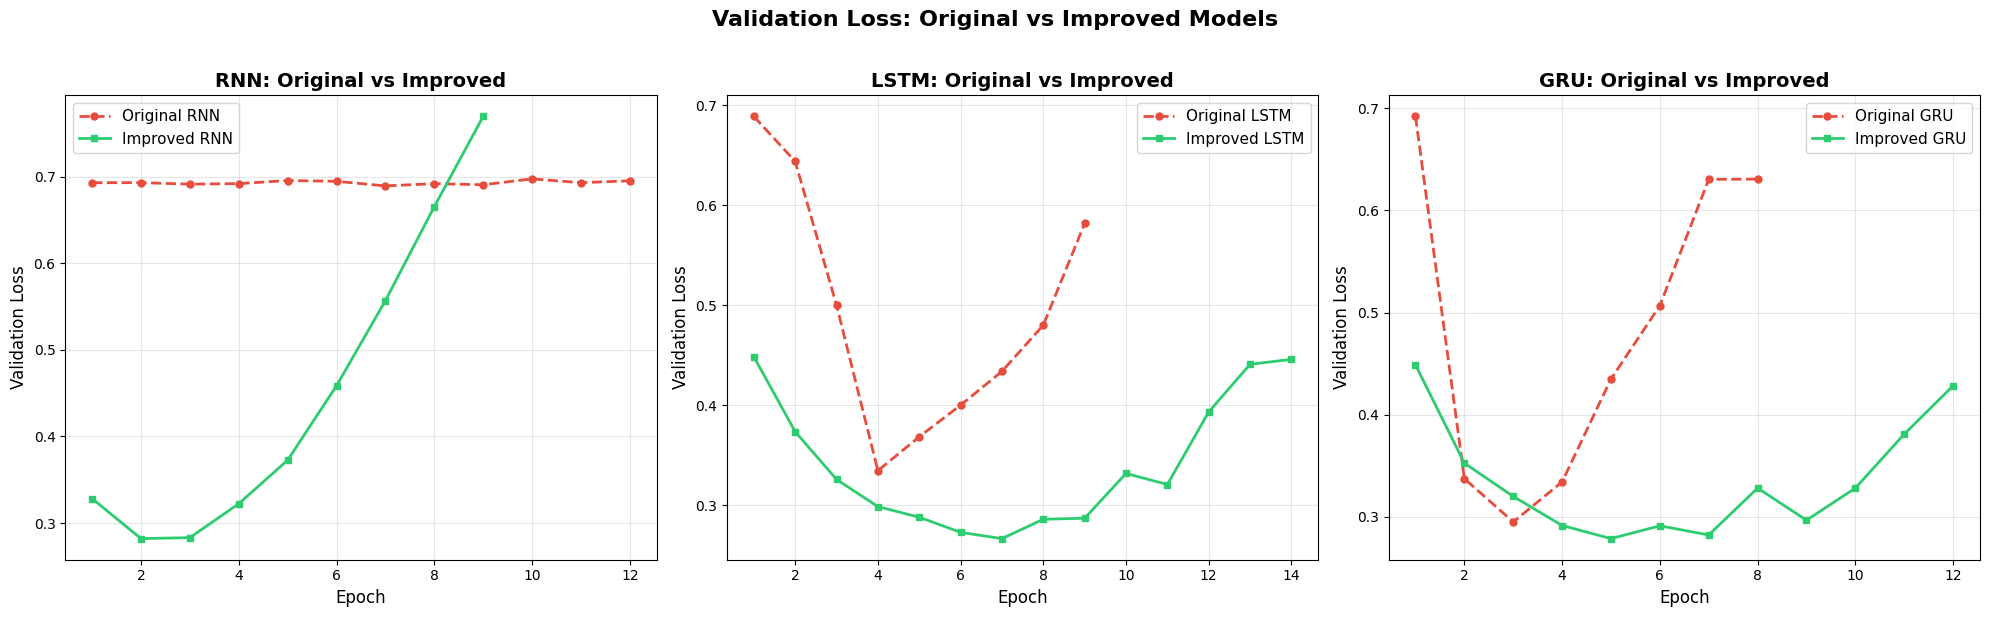

Saved: deliverable1_val_loss_comparison.png


In [ ]:
# ============ DELIVERABLE 1: Comparison Plot - Original vs Improved Validation Loss ============
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Colors
orig_color = '#e74c3c'  # Red for original
imp_color = '#2ecc71'   # Green for improved

# RNN Comparison
axes[0].plot(range(1, len(orig_rnn_history['val_loss'])+1), orig_rnn_history['val_loss'],
             label='Original RNN', color=orig_color, linewidth=2, marker='o', markersize=5, linestyle='--')
axes[0].plot(range(1, len(improved_rnn_history['val_loss'])+1), improved_rnn_history['val_loss'],
             label='Improved RNN', color=imp_color, linewidth=2, marker='s', markersize=5)
axes[0].set_title('RNN: Original vs Improved', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Validation Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# LSTM Comparison
axes[1].plot(range(1, len(orig_lstm_history['val_loss'])+1), orig_lstm_history['val_loss'],
             label='Original LSTM', color=orig_color, linewidth=2, marker='o', markersize=5, linestyle='--')
axes[1].plot(range(1, len(improved_lstm_history['val_loss'])+1), improved_lstm_history['val_loss'],
             label='Improved LSTM', color=imp_color, linewidth=2, marker='s', markersize=5)
axes[1].set_title('LSTM: Original vs Improved', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# GRU Comparison
axes[2].plot(range(1, len(orig_gru_history['val_loss'])+1), orig_gru_history['val_loss'],
             label='Original GRU', color=orig_color, linewidth=2, marker='o', markersize=5, linestyle='--')
axes[2].plot(range(1, len(improved_gru_history['val_loss'])+1), improved_gru_history['val_loss'],
             label='Improved GRU', color=imp_color, linewidth=2, marker='s', markersize=5)
axes[2].set_title('GRU: Original vs Improved', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Validation Loss', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Validation Loss: Original vs Improved Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('deliverable1_val_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: deliverable1_val_loss_comparison.png')


# PHASE 2: Ensemble System


### Implementing three voting strategies:
1. **Hard Voting** — Majority class wins
2. **Soft Voting** — Average of softmax probabilities
3. **Weighted Voting** — Models weighted by validation accuracy

In [ ]:
# ============ Ensemble Prediction System ============

def get_all_predictions(model, loader):
    """Get predictions, probabilities, and true labels from a model."""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            outputs = model(texts)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

# Get predictions from all three improved models
rnn_preds, rnn_probs, true_labels = get_all_predictions(improved_rnn, test_loader_new)
lstm_preds, lstm_probs, true_labels_check = get_all_predictions(improved_lstm, test_loader_new)
gru_preds, gru_probs, _ = get_all_predictions(improved_gru, test_loader_new)

# Verify labels match
assert np.array_equal(true_labels, true_labels_check), 'Label mismatch!'

# Individual model accuracies on test set
rnn_acc = np.mean(rnn_preds == true_labels) * 100
lstm_acc = np.mean(lstm_preds == true_labels) * 100
gru_acc = np.mean(gru_preds == true_labels) * 100

print(f'Individual Model Test Accuracies:')
print(f'  Improved RNN:  {rnn_acc:.2f}%')
print(f'  Improved LSTM: {lstm_acc:.2f}%')
print(f'  Improved GRU:  {gru_acc:.2f}%')

# Validation accuracies (best epoch) for weighting
rnn_val_acc = max(improved_rnn_history['val_acc'])
lstm_val_acc = max(improved_lstm_history['val_acc'])
gru_val_acc = max(improved_gru_history['val_acc'])
print(f'\nBest Validation Accuracies (for weighted voting):')
print(f'  RNN: {rnn_val_acc:.2f}% | LSTM: {lstm_val_acc:.2f}% | GRU: {gru_val_acc:.2f}%')

Individual Model Test Accuracies:
  Improved RNN:  87.61%
  Improved LSTM: 88.64%
  Improved GRU:  88.12%

Best Validation Accuracies (for weighted voting):
  RNN: 88.32% | LSTM: 88.83% | GRU: 88.52%


In [ ]:
# ============ Voting Strategies ============

# 1. HARD VOTING (Majority class wins)
def hard_voting(preds_list):
    """Majority vote across models. Ties broken by first model."""
    stacked = np.stack(preds_list, axis=0)  # (num_models, num_samples)
    ensemble_preds = []
    for i in range(stacked.shape[1]):
        votes = stacked[:, i]
        counts = np.bincount(votes, minlength=2)
        ensemble_preds.append(np.argmax(counts))
    return np.array(ensemble_preds)

# 2. SOFT VOTING (Average softmax probabilities)
def soft_voting(probs_list):
    """Average softmax probabilities across models."""
    avg_probs = np.mean(np.stack(probs_list, axis=0), axis=0)  # (num_samples, num_classes)
    return np.argmax(avg_probs, axis=1)

# 3. WEIGHTED VOTING (Weight by validation accuracy)
def weighted_voting(probs_list, weights):
    """Weighted average of softmax probabilities."""
    weights = np.array(weights)
    weights = weights / weights.sum()  # Normalize
    stacked = np.stack(probs_list, axis=0)  # (num_models, num_samples, num_classes)
    weighted_probs = np.average(stacked, axis=0, weights=weights)
    return np.argmax(weighted_probs, axis=1)

# Apply all strategies
hard_preds = hard_voting([rnn_preds, lstm_preds, gru_preds])
soft_preds = soft_voting([rnn_probs, lstm_probs, gru_probs])
weighted_preds = weighted_voting([rnn_probs, lstm_probs, gru_probs],
                                 [rnn_val_acc, lstm_val_acc, gru_val_acc])

# Compute ensemble accuracies
hard_acc = np.mean(hard_preds == true_labels) * 100
soft_acc = np.mean(soft_preds == true_labels) * 100
weighted_acc = np.mean(weighted_preds == true_labels) * 100

print(f'\nEnsemble Test Accuracies:')
print(f'  Hard Voting:     {hard_acc:.2f}%')
print(f'  Soft Voting:     {soft_acc:.2f}%')
print(f'  Weighted Voting: {weighted_acc:.2f}%')


Ensemble Test Accuracies:
  Hard Voting:     88.75%
  Soft Voting:     88.97%
  Weighted Voting: 88.97%


##  Accuracy Comparison Table


COMPREHENSIVE MODEL COMPARISON TABLE
                     Model Accuracy (%) Precision (%) Recall (%) F1-Score (%)
              Improved RNN        87.61         87.64      87.80        87.72
             Improved LSTM        88.64         87.09      90.93        88.97
              Improved GRU        88.12         86.27      90.89        88.52
    Ensemble (Hard Voting)        88.75         87.30      90.89        89.06
    Ensemble (Soft Voting)        88.97         87.69      90.87        89.25
Ensemble (Weighted Voting)        88.97         87.69      90.87        89.25


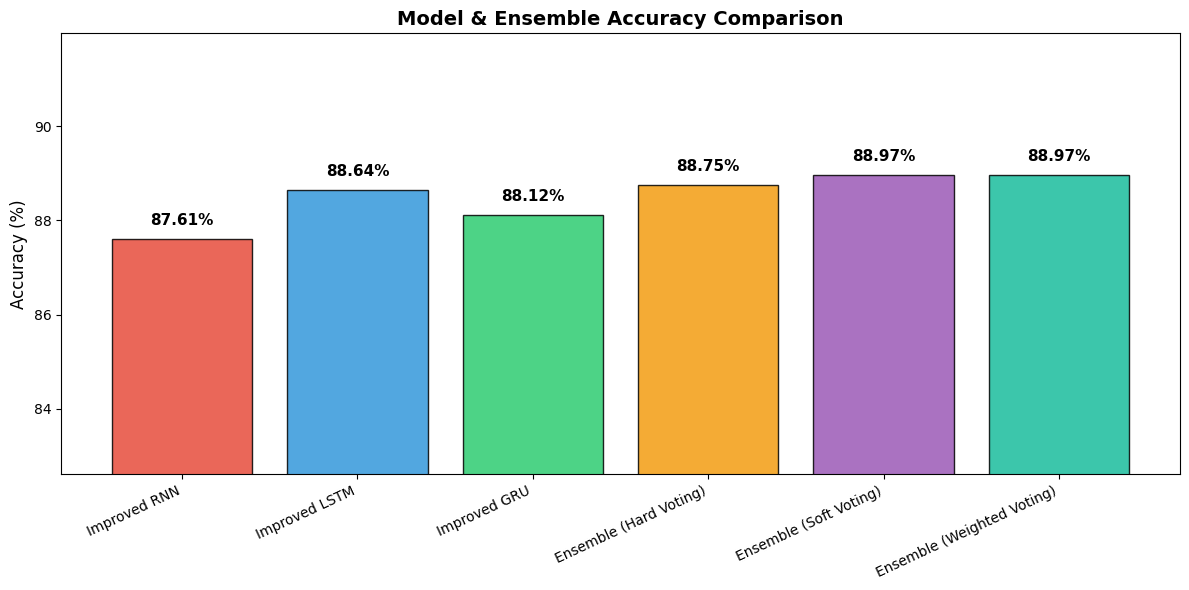

Saved: deliverable2_accuracy_comparison.png


In [ ]:
# ============ DELIVERABLE 2: Accuracy Table ============
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute metrics for all models/ensembles
def compute_metrics(y_true, y_pred, name):
    acc = np.mean(y_pred == y_true) * 100
    prec = precision_score(y_true, y_pred, average='binary') * 100
    rec = recall_score(y_true, y_pred, average='binary') * 100
    f1 = f1_score(y_true, y_pred, average='binary') * 100
    return {'Model': name, 'Accuracy (%)': f'{acc:.2f}',
            'Precision (%)': f'{prec:.2f}', 'Recall (%)': f'{rec:.2f}',
            'F1-Score (%)': f'{f1:.2f}'}

results = []
results.append(compute_metrics(true_labels, rnn_preds, 'Improved RNN'))
results.append(compute_metrics(true_labels, lstm_preds, 'Improved LSTM'))
results.append(compute_metrics(true_labels, gru_preds, 'Improved GRU'))
results.append(compute_metrics(true_labels, hard_preds, 'Ensemble (Hard Voting)'))
results.append(compute_metrics(true_labels, soft_preds, 'Ensemble (Soft Voting)'))
results.append(compute_metrics(true_labels, weighted_preds, 'Ensemble (Weighted Voting)'))

results_df = pd.DataFrame(results)

# Display as styled table
print('\n' + '='*85)
print('COMPREHENSIVE MODEL COMPARISON TABLE')
print('='*85)
print(results_df.to_string(index=False))
print('='*85)

# Visual bar chart
fig, ax = plt.subplots(figsize=(12, 6))
models_list = results_df['Model'].tolist()
accuracies = [float(x) for x in results_df['Accuracy (%)'].tolist()]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

bars = ax.bar(range(len(models_list)), accuracies, color=colors, edgecolor='black', alpha=0.85)
ax.set_xticks(range(len(models_list)))
ax.set_xticklabels(models_list, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model & Ensemble Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(min(accuracies) - 5, max(accuracies) + 3)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('deliverable2_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: deliverable2_accuracy_comparison.png')

##  Ensemble Correction Examples

In [ ]:
# ============ DELIVERABLE 3: 5 Examples Where Ensemble Corrected Individual Model Mistakes ============

# Find indices where at least one individual model was wrong but ensemble (soft voting) was correct
# Use soft_preds as the ensemble prediction
ensemble_correct = (soft_preds == true_labels)
rnn_wrong = (rnn_preds != true_labels)
lstm_wrong = (lstm_preds != true_labels)
gru_wrong = (gru_preds != true_labels)

# At least one model wrong AND ensemble correct AND models disagreed
disagreement = (rnn_preds != lstm_preds) | (lstm_preds != gru_preds) | (rnn_preds != gru_preds)
correction_mask = ensemble_correct & (rnn_wrong | lstm_wrong | gru_wrong) & disagreement
correction_indices = np.where(correction_mask)[0]

print(f'Total cases where ensemble corrected individual model mistakes: {len(correction_indices)}')
print()

# Get the original test texts for display
test_texts = test_data['cleaned_review'].values
sentiment_map = {0: 'Negative', 1: 'Positive'}

# Show 5 examples
print('='*90)
print('5 EXAMPLES WHERE INDIVIDUAL MODELS DISAGREED BUT ENSEMBLE GOT IT RIGHT')
print('='*90)

shown = 0
for idx in correction_indices:
    if shown >= 5:
        break
    text = test_texts[idx]
    if len(text) < 20:  # Skip very short reviews
        continue

    true_label = sentiment_map[true_labels[idx]]
    rnn_pred_label = sentiment_map[rnn_preds[idx]]
    lstm_pred_label = sentiment_map[lstm_preds[idx]]
    gru_pred_label = sentiment_map[gru_preds[idx]]
    ensemble_label = sentiment_map[soft_preds[idx]]

    # Only show if models actually disagree
    if rnn_preds[idx] == lstm_preds[idx] == gru_preds[idx]:
        continue

    shown += 1
    print(f'\nExample {shown}:')
    print(f'  Review (truncated): "{text[:120]}..."')
    print(f'  True Label:    {true_label}')
    print(f'  RNN Predicted: {rnn_pred_label} {"✓" if rnn_preds[idx] == true_labels[idx] else "✗"}')
    print(f'  LSTM Predicted:{lstm_pred_label} {"✓" if lstm_preds[idx] == true_labels[idx] else "✗"}')
    print(f'  GRU Predicted: {gru_pred_label} {"✓" if gru_preds[idx] == true_labels[idx] else "✗"}')
    print(f'  ENSEMBLE:      {ensemble_label} ✓ (Corrected!)')
    print(f'  Soft Probs: RNN={rnn_probs[idx]}, LSTM={lstm_probs[idx]}, GRU={gru_probs[idx]}')
    print('-'*90)

if shown < 5:
    print(f'\nNote: Only found {shown} clear disagreement+correction examples.')

Total cases where ensemble corrected individual model mistakes: 614

5 EXAMPLES WHERE INDIVIDUAL MODELS DISAGREED BUT ENSEMBLE GOT IT RIGHT

Example 1:
  Review (truncated): "the production quality cast premise authentic new england waterbury ct locale and lush john williams score should have r..."
  True Label:    Positive
  RNN Predicted: Positive ✓
  LSTM Predicted:Positive ✓
  GRU Predicted: Negative ✗
  ENSEMBLE:      Positive ✓ (Corrected!)
  Soft Probs: RNN=[0.3096296 0.6903704], LSTM=[0.4315297 0.5684703], GRU=[0.6216237  0.37837633]
------------------------------------------------------------------------------------------

Example 2:
  Review (truncated): "this movie was released originally as a soft x apparently with the explicit sex deleted later the producers relented sme..."
  True Label:    Positive
  RNN Predicted: Negative ✗
  LSTM Predicted:Positive ✓
  GRU Predicted: Negative ✗
  ENSEMBLE:      Positive ✓ (Corrected!)
  Soft Probs: RNN=[0.5266081  0.47339192], LSTM=[0

##  Visualizations: Confusion Matrices

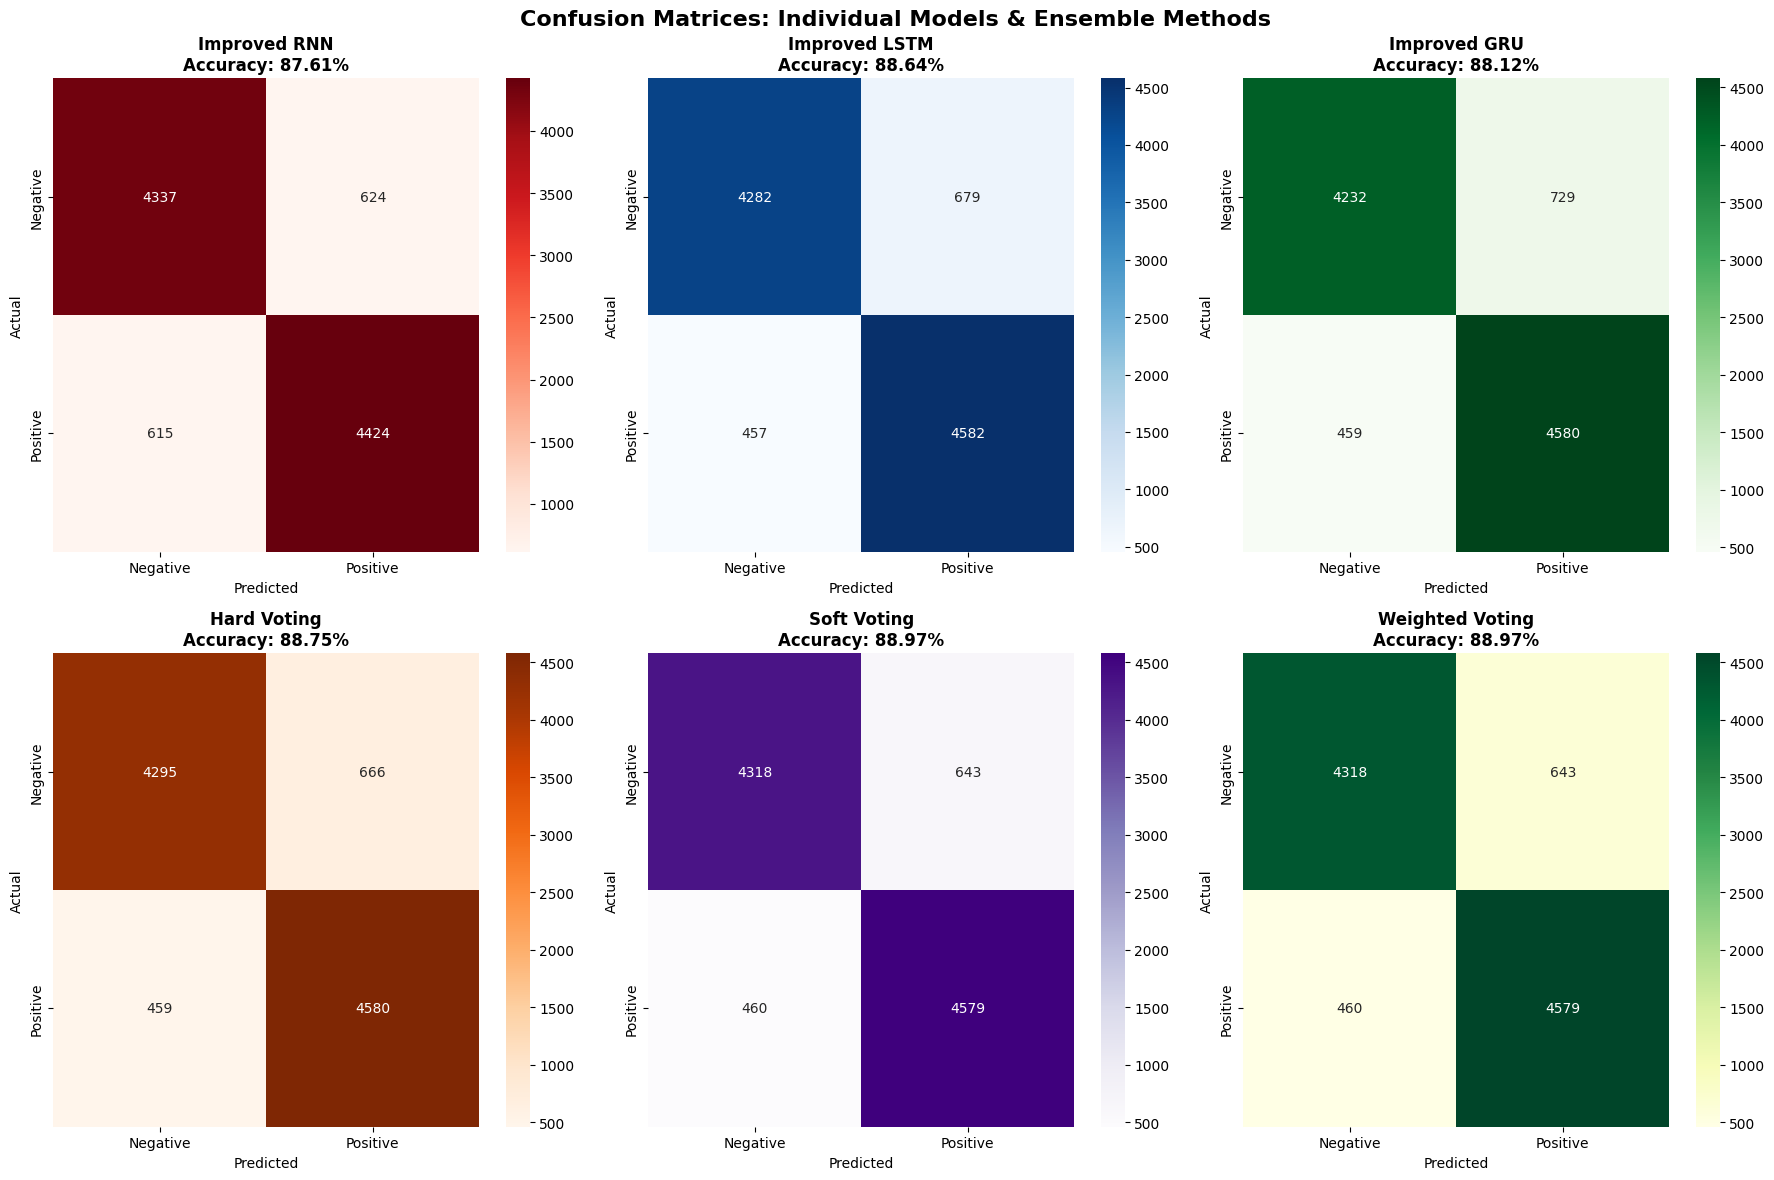

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

all_preds_dict = {
    'Improved RNN': rnn_preds,
    'Improved LSTM': lstm_preds,
    'Improved GRU': gru_preds,
    'Hard Voting': hard_preds,
    'Soft Voting': soft_preds,
    'Weighted Voting': weighted_preds
}

cmaps = ['Reds', 'Blues', 'Greens', 'Oranges', 'Purples', 'YlGn']

for idx, (name, preds) in enumerate(all_preds_dict.items()):
    row, col = idx // 3, idx % 3
    cm = confusion_matrix(true_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[idx], ax=axes[row, col],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    acc = 100 * np.trace(cm) / np.sum(cm)
    axes[row, col].set_title(f'{name}\nAccuracy: {acc:.2f}%', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Predicted')
    axes[row, col].set_ylabel('Actual')

plt.suptitle('Confusion Matrices: Individual Models & Ensemble Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

print(f'\nPhase 1 - Model Improvements:')
print(f'  RNN:  Best Val Acc = {max(improved_rnn_history["val_acc"]):.2f}% '
       f'(was underfitting → fixed with bidirectional + attention)')
print(f'  LSTM: Best Val Acc = {max(improved_lstm_history["val_acc"]):.2f}% '
       f'(was overfitting → fixed with dropout + reduced capacity)')
print(f'  GRU:  Best Val Acc = {max(improved_gru_history["val_acc"]):.2f}% '
       f'(was overfitting → fixed with dropout + reduced capacity)')
print(f'\nPhase 2 - Ensemble Results:')
print(f'  Hard Voting:     {hard_acc:.2f}%')
print(f'  Soft Voting:     {soft_acc:.2f}%')
print(f'  Weighted Voting: {weighted_acc:.2f}%')
print(f'\nBest overall: ', end='')
best = max([('Hard Voting', hard_acc), ('Soft Voting', soft_acc), ('Weighted Voting', weighted_acc)],
           key=lambda x: x[1])
print(f'{best[0]} with {best[1]:.2f}% accuracy')



Phase 1 - Model Improvements:
  RNN:  Best Val Acc = 88.32% (was underfitting → fixed with bidirectional + attention)
  LSTM: Best Val Acc = 88.83% (was overfitting → fixed with dropout + reduced capacity)
  GRU:  Best Val Acc = 88.52% (was overfitting → fixed with dropout + reduced capacity)

Phase 2 - Ensemble Results:
  Hard Voting:     88.75%
  Soft Voting:     88.97%
  Weighted Voting: 88.97%

Best overall: Soft Voting with 88.97% accuracy
